# [Data Understanding](https://rhindottire.github.io/Data-Mining/dataProcess.html#data-understanding)

In this phase we explore and become familiar with the data available for the project: **200 Indonesian news articles** collected from [detik.com](http://detik.com/) (100 `sport`, ids 1-100; 100 `finance`, ids 101-200). The goal is to identify the relevant data source, assess its quality, and obtain initial insights before moving on to the next phase.

*Key activities:*

- **Collect Data**: gather the articles using the official detik sitemap and `trafilatura` extraction, with a politeness delay of at least 1 second and a browser-like User-Agent.
- **Describe Data**: summarize the dataset (number of records, variables, data types) using descriptive statistics.
- **Explore Data**: run exploratory analysis to identify patterns, trends, and anomalies (text length, outliers).
- **Verify Data Quality**: check missing values, inconsistencies, duplicates, and label balance.

**Example**: the dataset contains 200 rows, 0 missing `isi_berita`, sequential `id` 1..200, and a balanced label distribution (100 sport / 100 finance).

The crawl results have already been produced and stored in `data/crawling_detik.csv` / `.json`, so this notebook **loads the results from file** instead of re-crawling (ethics details are in `Business.ipynb`).

**Required data columns**

| Column | Content |
|--------|---------|
| `id` | sequential integer 1-200 (1-100 = sport, 101-200 = finance) |
| `isi_berita` | main article text extracted by *trafilatura* |
| `label` | news category (`sport` or `finance`) |
| `url` | source article URL |



In [1]:
import re
import json
import time
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import trafilatura
from wordcloud import WordCloud

plt.style.use("seaborn-v0_8-whitegrid")


## 1. Collect Data

The functions below collect article URLs from the official detik sitemap and extract the main text with `trafilatura`. They were used once to build the stored dataset; running them again is optional (see Section 6).



In [2]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0 Safari/537.36"
}

POLITE_DELAY = 1.0  # seconds between requests


def get_urls_from_sitemap(sitemap_url):
    """Return all article URLs listed in one XML sitemap."""
    r = requests.get(sitemap_url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    return re.findall(r"<loc>\s*<!\[CDATA\[\s*([^\]]+?)\s*\]\]>\s*</loc>", r.text)


def collect_article_urls(kanal, limit=100):
    """Collect up to `limit` unique article URLs from a detik channel."""
    base = f"https://{kanal}.detik.com"
    idx = requests.get(f"{base}/sitemap.xml", headers=HEADERS, timeout=30)
    idx.raise_for_status()
    news_sitemaps = re.findall(r"https?://[^\s<\[]+?sitemap_news\.xml", idx.text)

    urls = set()
    for sm in news_sitemaps:
        try:
            urls.update(get_urls_from_sitemap(sm))
        except requests.RequestException:
            pass
        if len(urls) >= limit:
            break
        time.sleep(POLITE_DELAY)
    return list(urls)[:limit]


def crawl_article(url, retry=3, backoff=(1, 2, 4)):
    """Download one article and extract its main text with trafilatura."""
    for attempt in range(retry):
        try:
            downloaded = trafilatura.fetch_url(url)
            text = trafilatura.extract(downloaded, include_comments=False)
            if text:
                return text
        except Exception:
            pass
        if attempt < retry - 1:
            time.sleep(backoff[attempt])
    return None


def crawl_many(urls, label):
    """Crawl a list of URLs and return one record per article."""
    rows = []
    for i, url in enumerate(urls, start=1):
        rows.append({"url": url, "isi_berita": crawl_article(url), "label": label})
        if i % 25 == 0:
            print(f"{label}: {i}/{len(urls)} done")
        time.sleep(POLITE_DELAY)
    return rows


In [3]:
DATA_DIR = Path("data")
if not DATA_DIR.is_dir():
    DATA_DIR = Path("..") / "data"
if not DATA_DIR.is_dir():
    DATA_DIR = Path("..") / ".." / "data"

CSV_PATH = DATA_DIR / "crawling_detik.csv"
JSON_PATH = DATA_DIR / "crawling_detik.json"

if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
elif JSON_PATH.exists():
    df = pd.read_json(JSON_PATH)
else:
    raise FileNotFoundError("crawl results not found")


In [4]:
df.head()


,id,isi_berita,label,url
0,1,Misi Indonesia untuk meloloskan tim 3x3 ke Oli...,sport,https://sport.detik.com/basket/d-8608204/perba...
1,2,Inilah daftar pelatih NBA terbaik sepanjang ma...,sport,https://sport.detik.com/basket/d-8296454/10-pe...
2,3,"Pelita Jaya mendapat dukungan ""tenaga"" baru un...",sport,https://sport.detik.com/basket/d-8353921/agar-...
3,4,Center Miami Heat Bam Adebayo mencetak 83 poin...,sport,https://sport.detik.com/basket/d-8395308/heat-...
4,5,Campus League 2026 Basketball Jakarta sudah me...,sport,https://sport.detik.com/basket/d-8512605/campu...


## 2. Describe Data

Summarize the dataset: number of rows, columns, data types, and label distribution. We also add text-length features to describe the articles quantitatively.



In [5]:
df.shape


(200, 4)

In [6]:
df.dtypes


id            int64
isi_berita      str
label           str
url             str
dtype: object

In [7]:
df["label"].value_counts()


label
sport      100
finance    100
Name: count, dtype: int64

In [8]:
df["n_chars"] = df["isi_berita"].str.len()
df["n_words"] = df["isi_berita"].str.split().str.len()


In [9]:
df[["n_chars", "n_words"]].describe()


,n_chars,n_words
count,200.000000,200.000000
mean,2692.545000,372.600000
std,1321.075155,177.551012
min,924.000000,144.000000
25%,1922.750000,267.750000
50%,2439.500000,336.000000
75%,3010.750000,422.250000
max,14106.000000,1930.000000


## 3. Explore Data

Inspect representative articles and the distribution of text length to understand the structure of the news content and spot anomalies.



In [10]:
df[["id", "label", "url"]].head(3)


,id,label,url
0,1,sport,https://sport.detik.com/basket/d-8608204/perba...
1,2,sport,https://sport.detik.com/basket/d-8296454/10-pe...
2,3,sport,https://sport.detik.com/basket/d-8353921/agar-...


In [11]:
df[["id", "label", "url"]].tail(3)


,id,label,url
197,198,finance,https://finance.detik.com/berita-ekonomi-bisni...
198,199,finance,https://finance.detik.com/berita-ekonomi-bisni...
199,200,finance,https://finance.detik.com/berita-ekonomi-bisni...


In [12]:
# first sport article, first 300 characters
sport_row = df[df["label"] == "sport"].iloc[0]
print(sport_row["isi_berita"][:300])


Misi Indonesia untuk meloloskan tim 3x3 ke Olimpiade mulai digencarkan. PP Perbasi menggandeng Nicolas Widmer, salah satu agensi 3x3 yang dipercaya FIBA.
Kerja sama itu diawali dengan menggelar workshop selama dua hari (4-5/8), di Kantor Perbasi, GBK Arena Senayan. Dengan tujuan, memetakan jalan Ind


In [13]:
# first finance article, first 300 characters
finance_row = df[df["label"] == "finance"].iloc[0]
print(finance_row["isi_berita"][:300])


Direktorat Jenderal Pajak (DJP) menyampaikan sebanyak 38 wajib pajak (WP) di sektor besi dan baja telah masuk dalam berbagai tahapan penanganan per 26 Agustus 2026. Menteri Keuangan (Menkeu) Purbaya Yudhi Sadewa sebelumnya telah mengantongi daftar 40 perusahaan sektor baja yang diduga tidak patuh da


In [14]:
df.groupby("label")[["n_chars", "n_words"]].describe()


n_chars                                                         \
          count     mean          std     min      25%     50%     75%   
label                                                                    
finance   100.0  2828.03  1629.478875  1210.0  1888.75  2501.0  3234.0   
sport     100.0  2557.06   903.229322   924.0  1992.00  2409.0  2886.0   

                 n_words                                                  \
             max   count   mean         std    min    25%    50%     75%   
label                                                                      
finance  14106.0   100.0  379.9  216.371104  161.0  263.5  315.5  425.25   
sport     5809.0   100.0  365.3  128.230419  144.0  280.5  339.0  405.25   

                 
            max  
label            
finance  1930.0  
sport     801.0

In [15]:
df.nsmallest(3, "n_words")[["id", "label", "n_words"]]


,id,label,n_words
6,7,sport,144
191,192,finance,161
78,79,sport,170


In [16]:
df.nlargest(3, "n_words")[["id", "label", "n_words"]]


,id,label,n_words
147,148,finance,1930
100,101,finance,831
68,69,sport,801


### Visual overview

Plots help to quickly grasp the label balance, the text-length distribution, and the most frequent words per category.



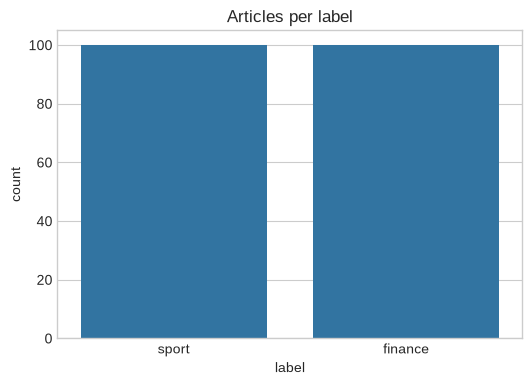

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="label", data=df, ax=ax)
ax.set_title("Articles per label")
plt.show()


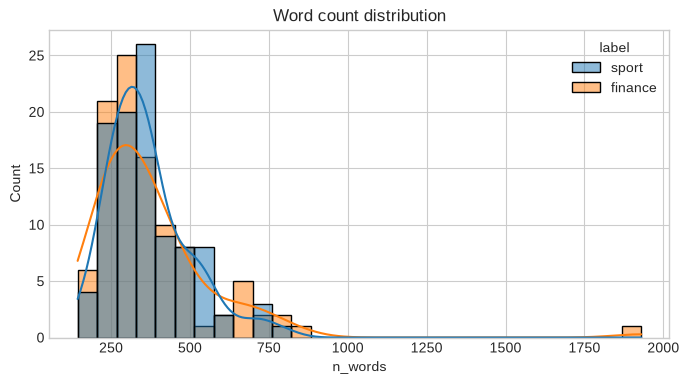

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x="n_words", hue="label", kde=True, ax=ax)
ax.set_title("Word count distribution")
plt.show()


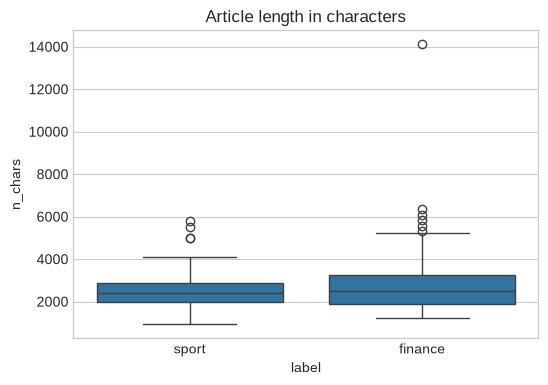

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="label", y="n_chars", data=df, ax=ax)
ax.set_title("Article length in characters")
plt.show()


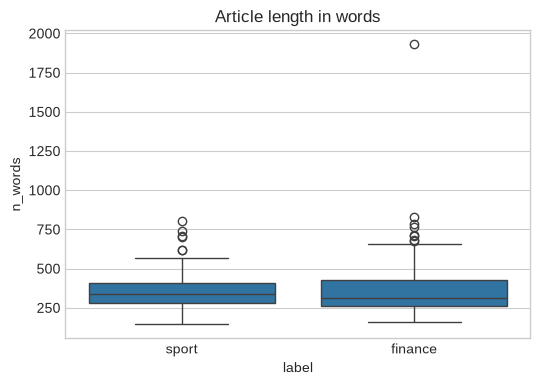

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="label", y="n_words", data=df, ax=ax)
ax.set_title("Article length in words")
plt.show()


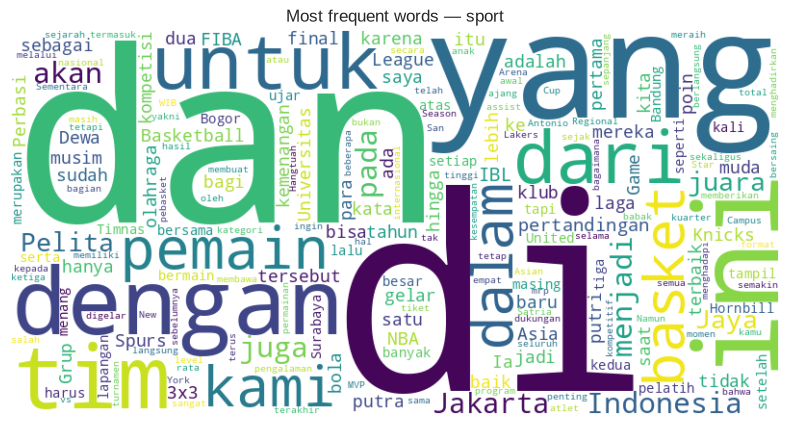

In [21]:
text = " ".join(df[df["label"] == "sport"]["isi_berita"])
wordcloud = WordCloud(width=800, height=400, background_color="white",
                      collocations=False).generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most frequent words — sport")
plt.show()


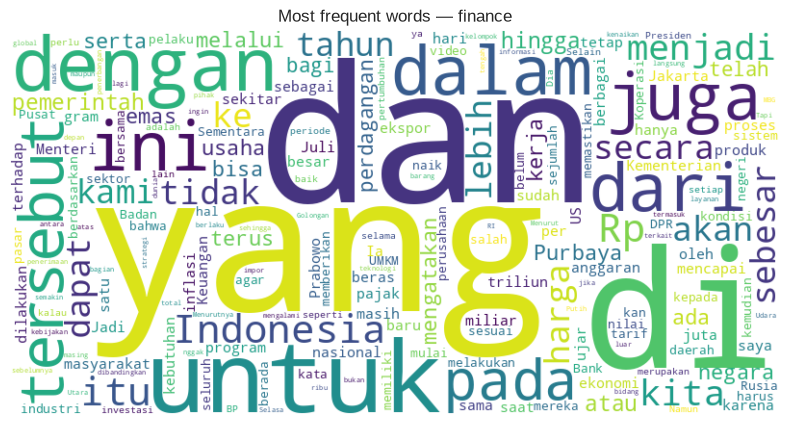

In [22]:
text = " ".join(df[df["label"] == "finance"]["isi_berita"])
wordcloud = WordCloud(width=800, height=400, background_color="white",
                      collocations=False).generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most frequent words — finance")
plt.show()


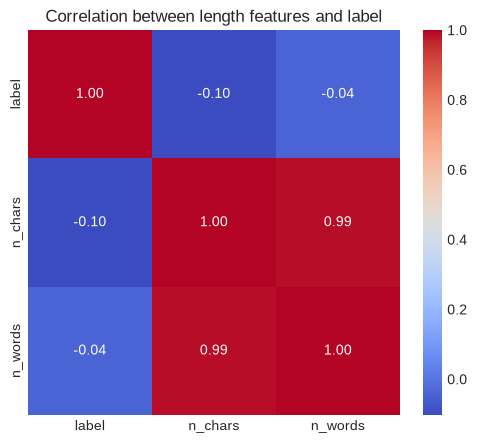

In [23]:
num_features = df[["label", "n_chars", "n_words"]].copy()
num_features["label"] = num_features["label"].astype("category").cat.codes

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(num_features.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation between length features and label")
plt.show()


## 4. Verify Data Quality

Check missing values, duplicate rows, duplicate URLs, sequential `id`, and label balance.



In [24]:
df[["id", "isi_berita", "label", "url"]].isna().sum()


id            0
isi_berita    0
label         0
url           0
dtype: int64

In [25]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [26]:
print("Duplicate URLs:", df["url"].duplicated().sum())


Duplicate URLs: 0


In [27]:
expected_ids = list(range(1, len(df) + 1))
print("Sequential id 1..200:", list(df["id"]) == expected_ids)


Sequential id 1..200: True


In [28]:
df["label"].value_counts()


label
sport      100
finance    100
Name: count, dtype: int64

In [29]:
distribution = df["label"].value_counts(normalize=True).mul(100).round(1)
distribution.index.name = "label"
print(distribution)


label
sport      50.0
finance    50.0
Name: proportion, dtype: float64


In [30]:
from urllib.parse import urlparse

host_label = df["url"].apply(
    lambda u: urlparse(u).netloc
    .replace("sport.detik.com", "sport")
    .replace("finance.detik.com", "finance")
)
print("label matches URL host:", (df["label"] == host_label).all())


label matches URL host: True


### Outlier analysis

A few articles are noticeably shorter or longer than the rest. Using the
interquartile range (IQR), a value is marked as an outlier when it lies more
than 1.5 x IQR below the first quartile or above the third quartile.


In [31]:
def detect_outliers(col):
    series = df[col]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper


In [32]:
for col in ["n_chars", "n_words"]:
    outliers, lower, upper = detect_outliers(col)
    print(f"{col}: {len(outliers)} outliers outside [{lower:.0f}, {upper:.0f}]")


n_chars: 15 outliers outside [291, 4643]
n_words: 12 outliers outside [36, 654]


### Takeaways

- No missing values, empty articles, duplicate rows, or duplicate URLs; `id` runs
  from 1 to 200 without gaps.
- Every article label matches the URL host, and the two classes are balanced at
  50 % each, so no rebalancing is needed.
- The length features `n_chars` and `n_words` correlate strongly and mostly capture
  the same information; the text itself remains the main modeling input.
- A few length outliers exist but are kept - both short and long articles carry
  useful signal for classification.
- The crawl does not include publication dates, so timeliness cannot be assessed yet.


## 5. Re-crawl (Optional)

In case the stored files must be regenerated, running the cells below re-collects 100 sport + 100 finance articles from detik.com and overwrites the saved CSV / JSON. It sends live requests, needs a stable connection, and takes a few minutes.



In [33]:
_re_crawl = False

if _re_crawl:
    sport_urls = collect_article_urls("sport", 100)
    finance_urls = collect_article_urls("finance", 100)
    rows = crawl_many(sport_urls, "sport") + crawl_many(finance_urls, "finance")

    df = pd.DataFrame(rows)
    df.insert(0, "id", range(1, len(df) + 1))
    df = df.dropna(subset=["isi_berita"]).reset_index(drop=True)
    df.to_csv(CSV_PATH, index=False, encoding="utf-8")
    df.to_json(JSON_PATH, orient="records", force_ascii=False, indent=2)
    print(f"Re-crawl done: {len(df)} articles saved.")
